# Multi-Armed Bandit Portfolio Allocation

Each period, an agent chooses **one asset (arm)** to hold, observes its return (the reward), and updates its beliefs. The challenge is the **exploration vs exploitation** trade-off in a market whose best asset changes over time.

**Agents compared**

| Agent | Idea |
|---|---|
| ε-greedy | Exploit the best estimated asset, explore at random with probability ε |
| UCB1 | Pick the asset with the highest optimistic bound (mean + uncertainty bonus) |
| Thompson sampling | Sample a plausible mean for each asset from a Bayesian posterior, pick the highest |
| Discounted Thompson | Same, but forgets old rewards so it can adapt to **regime changes** |

**Benchmarks:** equal-weight portfolio, random choice, and an oracle that always knows the best asset (used to measure regret).

> Returns are **simulated** from a regime-switching model so results are reproducible and the true best asset is known.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 1. Simulated market with regime changes

Five assets, weekly returns over 10 years (520 periods). The market switches between **three regimes** (bull, bear, rotation). In each regime the expected return ranking of the assets changes, so an agent that never re-explores gets stuck on the wrong asset.

In [2]:
assets = ["Equities", "Bonds", "Gold", "Commodities", "Cash"]
T = 520

# Weekly expected returns and volatilities per regime
mu = {
    "Bull":     np.array([0.0060, 0.0005, 0.0005, 0.0030, 0.0006]),
    "Bear":     np.array([-0.0060, 0.0025, 0.0040, -0.0030, 0.0006]),
    "Rotation": np.array([0.0005, 0.0000, 0.0010, 0.0070, 0.0006]),
}
vol = np.array([0.015, 0.006, 0.012, 0.018, 0.001])

# Regime schedule (weeks)
schedule = [("Bull", 150), ("Bear", 90), ("Rotation", 110), ("Bull", 100), ("Bear", 70)]
regimes = np.concatenate([[name] * n for name, n in schedule])
assert len(regimes) == T

rng = np.random.default_rng(7)
true_means = np.array([mu[g] for g in regimes])
returns = true_means + rng.standard_normal((T, len(assets))) * vol
returns = pd.DataFrame(returns, columns=assets)

summary = pd.DataFrame({
    "Ann. return": returns.mean() * 52,
    "Ann. vol": returns.std() * np.sqrt(52),
})
summary["Sharpe"] = summary["Ann. return"] / summary["Ann. vol"]
display(summary.round(3))

,Ann. return,Ann. vol,Sharpe
Equities,0.002,0.109,0.015
Bonds,0.069,0.045,1.527
Gold,0.070,0.088,0.792
Commodities,0.062,0.132,0.474
Cash,0.028,0.007,4.040


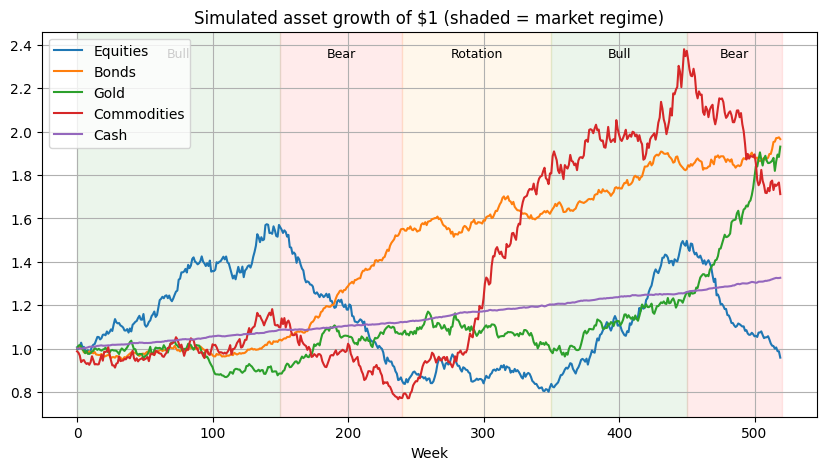

In [3]:
fig, ax = plt.subplots()
(1 + returns).cumprod().plot(ax=ax)
start = 0
for name, n in schedule:
    ax.axvspan(start, start + n, alpha=0.08, color={"Bull": "green", "Bear": "red", "Rotation": "orange"}[name])
    ax.text(start + n / 2, ax.get_ylim()[1] * 0.97, name, ha="center", va="top", fontsize=9)
    start += n
ax.set_title("Simulated asset growth of $1 (shaded = market regime)"); ax.set_xlabel("Week")
plt.show()

## 2. Bandit agents

In [4]:
class EpsilonGreedy:
    name = "ε-greedy (ε=0.1)"
    def __init__(self, k, eps=0.1, seed=0):
        self.eps, self.rng = eps, np.random.default_rng(seed)
        self.n, self.mean = np.zeros(k), np.zeros(k)
    def select(self, t):
        if t < len(self.n):                      # try each arm once
            return t
        if self.rng.random() < self.eps:
            return self.rng.integers(len(self.n))
        return int(np.argmax(self.mean))
    def update(self, a, r):
        self.n[a] += 1
        self.mean[a] += (r - self.mean[a]) / self.n[a]


class UCB1:
    name = "UCB1"
    def __init__(self, k, c=0.02, seed=0):
        self.c = c                               # bonus scaled to the size of weekly returns
        self.n, self.mean = np.zeros(k), np.zeros(k)
    def select(self, t):
        if t < len(self.n):
            return t
        bonus = self.c * np.sqrt(2 * np.log(t + 1) / self.n)
        return int(np.argmax(self.mean + bonus))
    def update(self, a, r):
        self.n[a] += 1
        self.mean[a] += (r - self.mean[a]) / self.n[a]


class GaussianThompson:
    # Normal-Normal conjugate model with known noise variance.
    # gamma < 1 discounts past observations, letting the agent adapt to regime changes.
    def __init__(self, k, gamma=1.0, noise=0.02, prior_sd=0.01, seed=0):
        self.gamma, self.noise2, self.prior_prec = gamma, noise**2, 1 / prior_sd**2
        self.rng = np.random.default_rng(seed)
        self.sum_r, self.cnt = np.zeros(k), np.zeros(k)
        self.name = "Thompson sampling" if gamma == 1.0 else f"Discounted Thompson (γ={gamma})"
    def select(self, t):
        prec = self.prior_prec + self.cnt / self.noise2
        post_mean = (self.sum_r / self.noise2) / prec
        return int(np.argmax(self.rng.normal(post_mean, 1 / np.sqrt(prec))))
    def update(self, a, r):
        self.sum_r *= self.gamma; self.cnt *= self.gamma
        self.sum_r[a] += r; self.cnt[a] += 1

## 3. Backtest

At each week $t$ the agent picks an asset, earns that asset's realised return, then updates. **Regret** is the gap between the oracle's expected return (best true mean) and the expected return of the asset chosen.

In [5]:
R = returns.values
best_mean = true_means.max(axis=1)

def run(agent):
    picks, rewards = np.zeros(T, int), np.zeros(T)
    for t in range(T):
        a = agent.select(t)
        picks[t], rewards[t] = a, R[t, a]
        agent.update(a, R[t, a])
    regret = np.cumsum(best_mean - true_means[np.arange(T), picks])
    return picks, rewards, regret

k = len(assets)
agents = [EpsilonGreedy(k), UCB1(k), GaussianThompson(k), GaussianThompson(k, gamma=0.97)]
results = {ag.name: run(ag) for ag in agents}

# Benchmarks
rng_b = np.random.default_rng(1)
rand_picks = rng_b.integers(k, size=T)
results["Random"] = (rand_picks, R[np.arange(T), rand_picks],
                     np.cumsum(best_mean - true_means[np.arange(T), rand_picks]))
oracle_picks = true_means.argmax(axis=1)
results["Oracle (knows best asset)"] = (oracle_picks, R[np.arange(T), oracle_picks], np.zeros(T))
equal_weight = R.mean(axis=1)

## 4. Performance

In [6]:
def metrics(r):
    wealth = np.cumprod(1 + r)
    dd = wealth / np.maximum.accumulate(wealth) - 1
    ann_ret = (wealth[-1]) ** (52 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(52)
    return {"Total return": wealth[-1] - 1, "Ann. return": ann_ret, "Ann. vol": ann_vol,
            "Sharpe": r.mean() / r.std() * np.sqrt(52), "Max drawdown": dd.min()}

table = {name: {**metrics(rw), "Final regret": rg[-1]} for name, (pk, rw, rg) in results.items()}
table["Equal weight"] = {**metrics(equal_weight), "Final regret": np.nan}
perf = pd.DataFrame(table).T.sort_values("Sharpe", ascending=False)
print(perf.round(3).to_string()); display(perf.style.format({"Total return": "{:.1%}", "Ann. return": "{:.1%}", "Ann. vol": "{:.1%}",
                           "Sharpe": "{:.2f}", "Max drawdown": "{:.1%}", "Final regret": "{:.3f}"}))

                              Total return  Ann. return  Ann. vol  Sharpe  Max drawdown  Final regret
Oracle (knows best asset)           11.359        0.286     0.110   2.354        -0.090         0.000
UCB1                                 2.807        0.143     0.096   1.437        -0.156         1.493
ε-greedy (ε=0.1)                     0.908        0.067     0.055   1.207        -0.077         2.254
Equal weight                         0.574        0.046     0.039   1.198        -0.081           NaN
Discounted Thompson (γ=0.97)         0.986        0.071     0.091   0.799        -0.176         1.897
Thompson sampling                    0.686        0.054     0.084   0.666        -0.145         2.103
Random                               0.112        0.011     0.086   0.166        -0.252         2.370


,Total return,Ann. return,Ann. vol,Sharpe,Max drawdown,Final regret
Oracle (knows best asset),1135.9%,28.6%,11.0%,2.35,-9.0%,0.000
UCB1,280.7%,14.3%,9.6%,1.44,-15.6%,1.493
ε-greedy (ε=0.1),90.8%,6.7%,5.5%,1.21,-7.7%,2.254
Equal weight,57.4%,4.6%,3.9%,1.20,-8.1%,nan
Discounted Thompson (γ=0.97),98.6%,7.1%,9.1%,0.80,-17.6%,1.897
Thompson sampling,68.6%,5.4%,8.4%,0.67,-14.5%,2.103
Random,11.2%,1.1%,8.6%,0.17,-25.2%,2.370


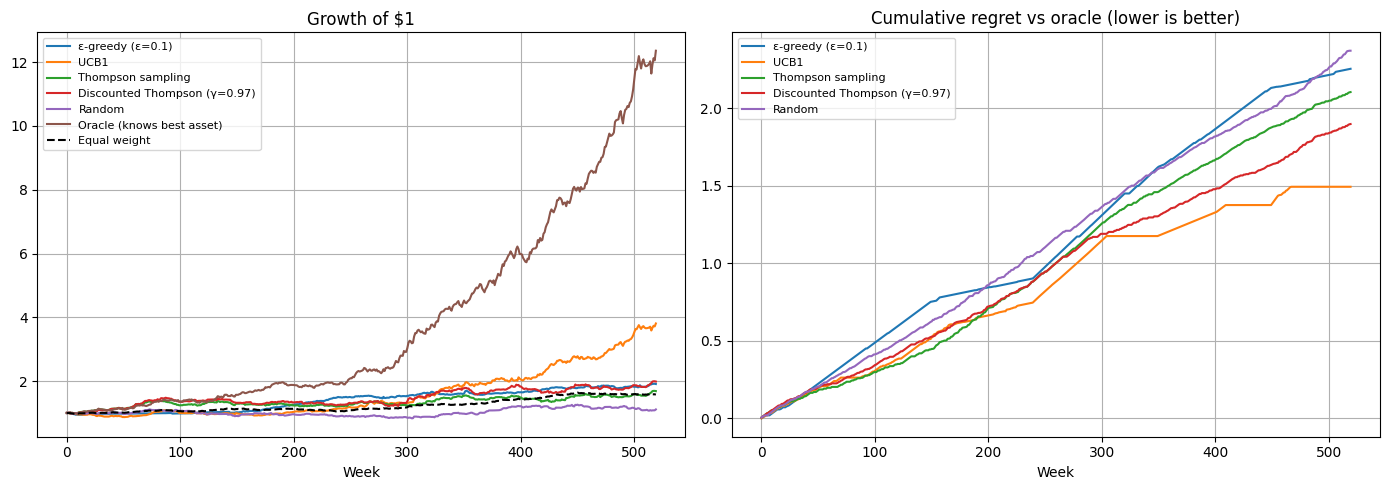

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, (pk, rw, rg) in results.items():
    axes[0].plot(np.cumprod(1 + rw), label=name)
axes[0].plot(np.cumprod(1 + equal_weight), "k--", label="Equal weight")
axes[0].set_title("Growth of $1"); axes[0].set_xlabel("Week"); axes[0].legend(fontsize=8)

for name, (pk, rw, rg) in results.items():
    if not name.startswith("Oracle"):
        axes[1].plot(rg, label=name)
axes[1].set_title("Cumulative regret vs oracle (lower is better)"); axes[1].set_xlabel("Week"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. What did the agents learn?

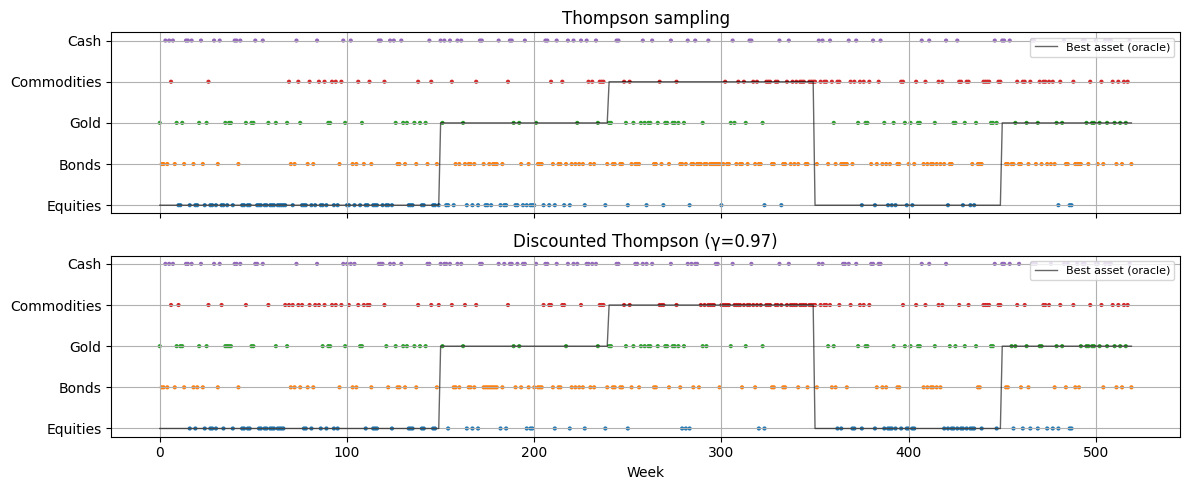

Share of weeks the agent held the truly best asset:
UCB1                            37.1%
Discounted Thompson (γ=0.97)    26.7%
Thompson sampling               22.3%
Random                          17.5%
ε-greedy (ε=0.1)                 4.8%
dtype: str


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, name in zip(axes, ["Thompson sampling", "Discounted Thompson (γ=0.97)"]):
    pk = results[name][0]
    ax.scatter(np.arange(T), pk, s=4, c=pk, cmap="tab10", vmin=0, vmax=9)
    ax.plot(oracle_picks, "k-", lw=1, alpha=0.6, label="Best asset (oracle)")
    ax.set_yticks(range(k), assets); ax.set_title(name); ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Week")
plt.tight_layout(); plt.show()

hit = {name: (pk == oracle_picks).mean() for name, (pk, _, _) in results.items() if not name.startswith("Oracle")}
print("Share of weeks the agent held the truly best asset:")
print(pd.Series(hit).sort_values(ascending=False).map("{:.1%}".format))

## 6. Takeaways

- **UCB1 performs best here** (Sharpe 1.44, 37% of weeks in the truly best asset), because its uncertainty bonus keeps re-testing assets it has not sampled recently, which helps after regime changes. Its bonus is scaled to the size of weekly returns ($c = 0.02$); with the textbook scale it would explore far too much.
- **ε-greedy gets stuck.** It locks onto an early winner and holds the best asset in only 5% of weeks: random exploration is too blunt to detect a regime change.
- **Forgetting helps Thompson sampling.** Discounting old rewards (γ = 0.97) lifts total return from 69% to 99% and lowers regret versus standard Thompson sampling, which averages over the whole history.
- **All agents stay far from the oracle**, and single-asset bets carry larger drawdowns than the diversified equal-weight portfolio. Beating equal weight on return does not mean beating it on risk.

**Limitations:** simulated returns; one random seed; no transaction costs (frequent switching would be penalised in practice); one asset held per period rather than portfolio weights; results are sensitive to hyperparameters (ε, UCB bonus, discount γ).

**Extensions:** real market data, transaction costs, several seeds with confidence intervals, contextual bandits using signals (momentum, volatility), and allocating weights across several arms.